In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact

import sonar_equation as SE


# An introduction to underwater accoustics: The active sonar equation 

At the heart of telecommunications lies the link budget, an essential tool for dimensioning systems based on target performance, such as received signal strength. Its acoustic counterpart is the SONAR equation, which serves the same purpose by characterizing acoustic systems through the lens of marine propagation parameters.

To derive the active sonar equation, we first define the Signal-to-Noise Ratio (SNR) as:
$$ SNR_{\text{dB}} = S_{\text{T, dB}} - B_{\text{L, dB} \tag{1.0}}$$

Where $S_{\text{T, dB}}$ represents the received signal level and $B_{\text{L, dB}}$ the background noise level, both expressed in dB.

The received signal $S_{\text{T, dB}}$ can be expanded as follows:
$$S_{\text{T, dB}} = SL_{\text{dB}} - 2 \cdot TL_{\text{dB}} + TS_{\text{dB}} \tag{1.1}$$

In this expression, $SL_{\text{dB}}$ is the Source Level, $TL_{\text{dB}}$ is the Transmission Loss (multiplied by two to account for the round-trip path), and $TS_{\text{dB}}$ is the Target Strength.

Similarly, the background level $B_{\text{L, dB}}$ is defined by:
$$B_{\text{L, dB}} = NL_{\text{dB}} - DI_{\text{dB}} \tag{1.2}$$

Where $NL_{\text{dB}}$ is the Noise Level and $DI_{\text{dB}}$ is the Directivity Index.

By substituting equations $(1.1)$ and $(1.2)$ into $(1.0)$, we obtain the complete Active Sonar Equation:
$$SNR_{\text{dB}} = SL_{\text{dB}} - 2 \cdot TL_{\text{dB}} + TS_{\text{dB}} - (NL_{\text{dB}} - DI_{\text{dB}}) \tag{1.3}$$

The goal of this Notebook is to explore the various components of this equation to understand how the propagation channel and the system's characteristics influence communication performance. We will conduct this study iteratively; parameters not currently under investigation will be held constant at specified values.

## Transmission Loss (TL)

--- 

This parameter represents the attenuation of the acoustic wave as it propagates through the medium. Transmission losses are generally decomposed into two distinct phenomena: geometrical spreading losses and absorption spreading losses. 

### Geometric spreading loss

If we assume a homogeneous and infinite medium—a valid hypothesis for deep-sea transmissions far from boundaries—and a point source radiating uniformly in all directions, the intensity of the acoustic wave decreases as the wavefront expands.While the total energy is conserved, the power is distributed over the surface of an expanding sphere with radius $R$. We define the Transmission Loss ($TL$) as follows:
$$TL_{\text{dB}} = 10 \log_{10}\left(\frac{I_0}{I}\right) \tag{1.4}$$
Where $I_0$ is the reference intensity (measured at 1 meter from the source), defined as $I_0 = \frac{P}{4 \pi (1)^2}$ (with $P$ being the emitted power). The intensity $I$ at a given radius $R$ is $I = \frac{P}{4 \pi R^2}$, as the power $P$ remains constant across the expanding sphere. We can then rewrite $(1.4)$ as:

$$TL_{\text{dB}} = 10 \log_{10}\left(\frac{\frac{P}{4 \pi}}{\frac{P}{4 \pi R^2}}\right) = 20 \log_{10}(R) \tag{1.5}$$

Where $R$ is the distance traveled by the acoustic wave (in meters).In shallow water environments, the acoustic wave is bounded by the sea surface and the seabed. Beyond a certain distance (roughly equal to the water depth), the wavefront can no longer expand vertically and instead spreads horizontally.In this configuration, the acoustic energy is distributed over the surface of a cylinder ($2\pi R \cdot H$, where $H$ is the water depth) rather than a sphere. Consequently, the intensity decreases more slowly with distance. Similarly, we define the Transmission Loss for the cylindrical case as:
$$TL_{\text{dB}} = 10 \log_{10}\left(\frac{\frac{P}{2 \pi H}}{\frac{P}{2 \pi R H}}\right) = 10 \log_{10}(R) \tag{1.6}$$


**Experiment**: Visualize the SNR evolution in both spherical and cylindrical spreading case

First of all, we'll initialize an instance of the sonar equation with the following parameters: 

- $SL_{dB} = 30 dB$, 
- $TS_{dB} = 5$,
- $NL_{dB} = 30$,
- $DI_{dB} = 0$ (the case of an omnidirectional hydrophone), 
- $DT_{dB} = -30 dB$ 




In [ ]:
sonar_equation = SE.SonarEquation(30, 5, 30, 0, -30)

By plotting the SNR curves for both cases, we can clearly observe the impact of the propagation medium on system performance. Due to the better conservation of acoustic intensity in the cylindrical spreading scenario, the SNR remains above the detection threshold for a significantly longer distance compared to the spherical case.

In practical terms, this means that in shallow water or acoustic waveguides, a sonar system will have a much greater operational range because the energy is "trapped" and directed, rather than being lost in all directions.

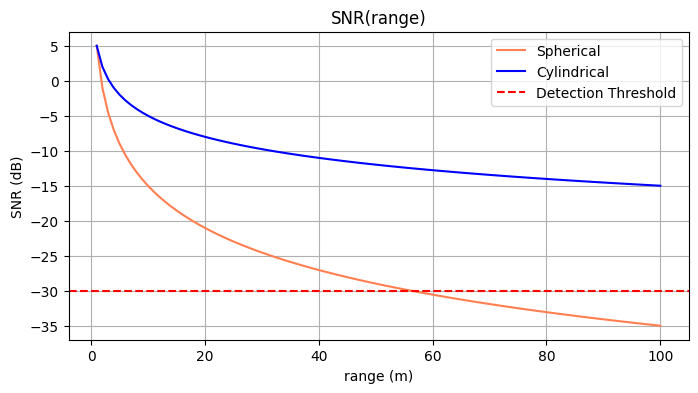

In [3]:
range = np.linspace(1, 100, 100)
SNR_s = sonar_equation.compute_SNR(range=range, model='spherical')
SNR_c = sonar_equation.compute_SNR(range=range, model='cylindrical')
plt.figure(figsize=(8, 4))
plt.plot(range, SNR_s, color='coral', label='Spherical')
plt.plot(range, SNR_c, color='blue', label='Cylindrical')
plt.axhline(y=sonar_equation.detection_threshold, color='red', linestyle='--', label='Detection Threshold')
plt.title("SNR(range)")
plt.xlabel("range (m)")
plt.ylabel("SNR (dB)")
plt.grid(True)
plt.legend()
plt.show()